<a href="https://colab.research.google.com/github/kalinapeterson12/Data-201-Labs/blob/main/Assignments/Week_2_HW_DATA_201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Importing the dataset


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Importing Data
college = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/College.csv")
college.head()

Mounted at /content/drive


,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
college.index

RangeIndex(start=0, stop=777, step=1)

Dataset Metadata: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html#:~:text=The%20Boston%20Housing%20Dataset,the%20area%20of%20Boston%20Mass

## Question 8

In [4]:
college2 = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/College.csv", index_col = 0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis = 1)
college3 = college3.set_index('College')
college3.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [5]:
college = college3

In [6]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


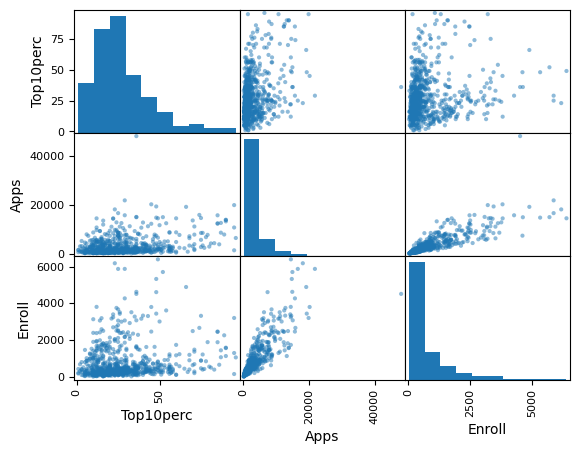

In [7]:
pd.plotting.scatter_matrix(college[['Top10perc',
                                 'Apps',
                                 'Enroll']]);

<Axes: title={'center': 'Outstate'}, xlabel='Private'>

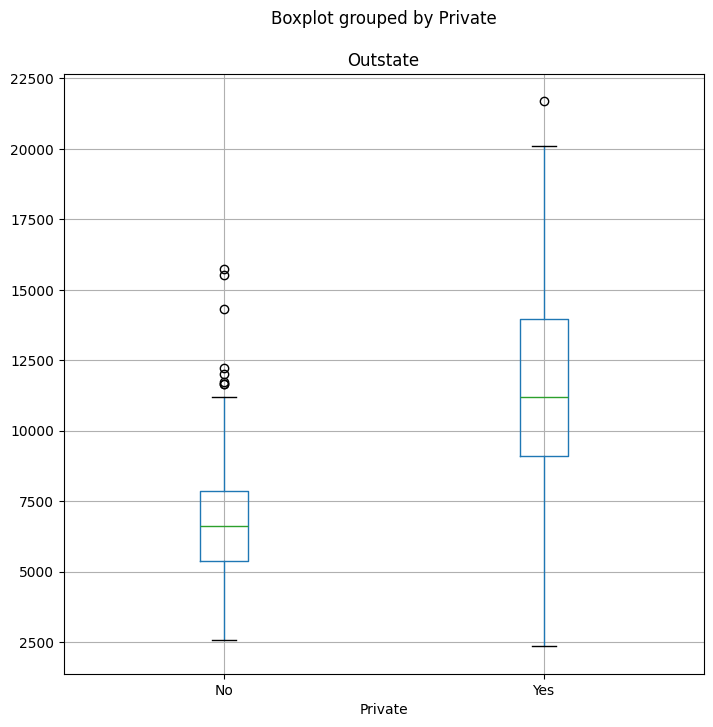

In [8]:
from matplotlib.pyplot import subplots

fig, ax = subplots(figsize = (8,8))
college.boxplot('Outstate', by = 'Private', ax = ax)

In [9]:
college['Elite'] = pd.cut(college['Top10perc'],
                          [0, 0.5, 1],
                          labels = ['No', 'Yes'])

In [10]:
print(college['Elite'].value_counts())


Elite
Yes    3
No     0
Name: count, dtype: int64


<Axes: title={'center': 'Outstate'}, xlabel='Elite'>

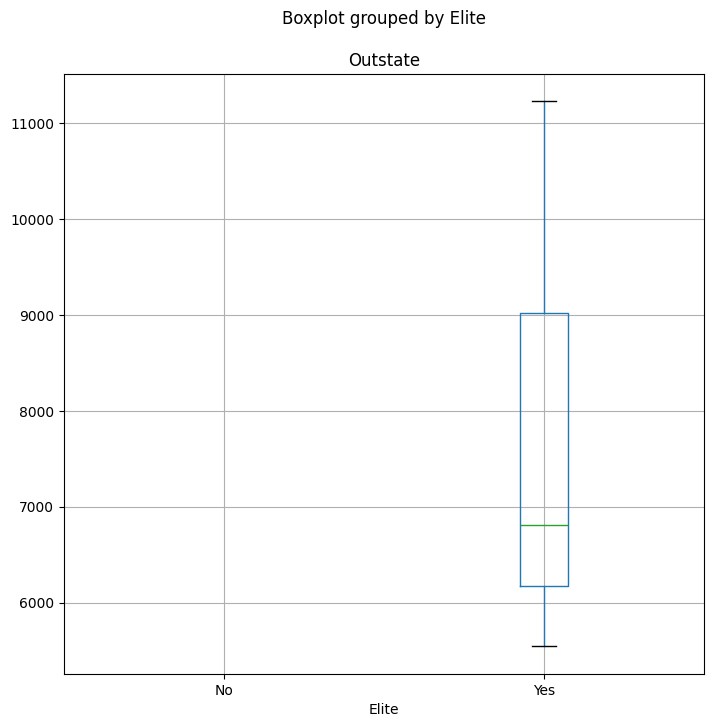

In [11]:
fig, ax = subplots(figsize = (8,8))
college.boxplot('Outstate', by = 'Elite', ax = ax)

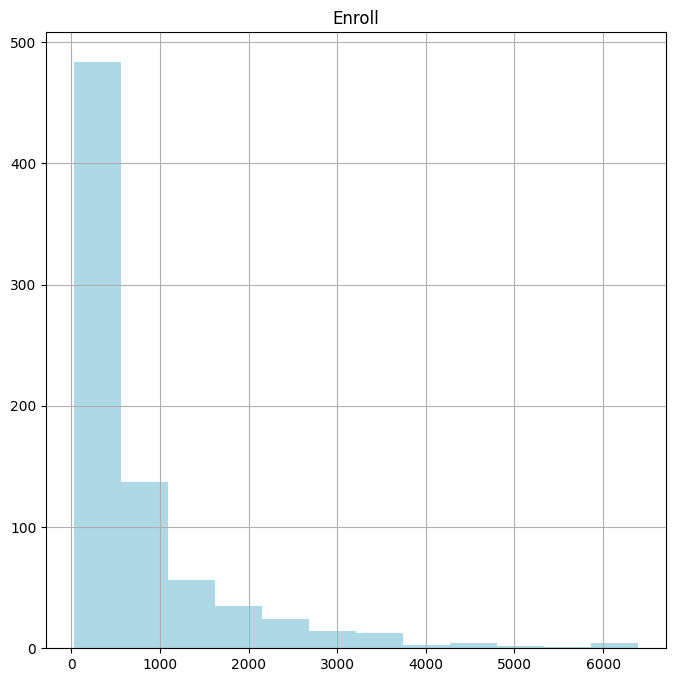

In [12]:
fig, ax = subplots(figsize = (8,8))
college.hist('Enroll', color = 'lightblue', bins = 12, ax = ax);

 Most colleges in this dataset have about 0-500 new students enrolled.

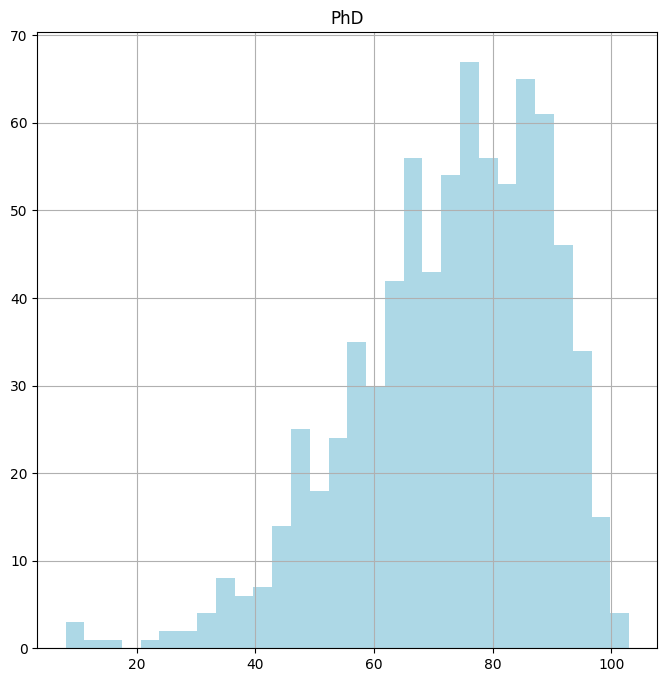

In [13]:
fig, ax = subplots(figsize = (8,8))
college.hist('PhD', color = 'lightblue', bins = 30, ax = ax);

For most colleges, a large percentage of the staff (over 60%) have PhDs.

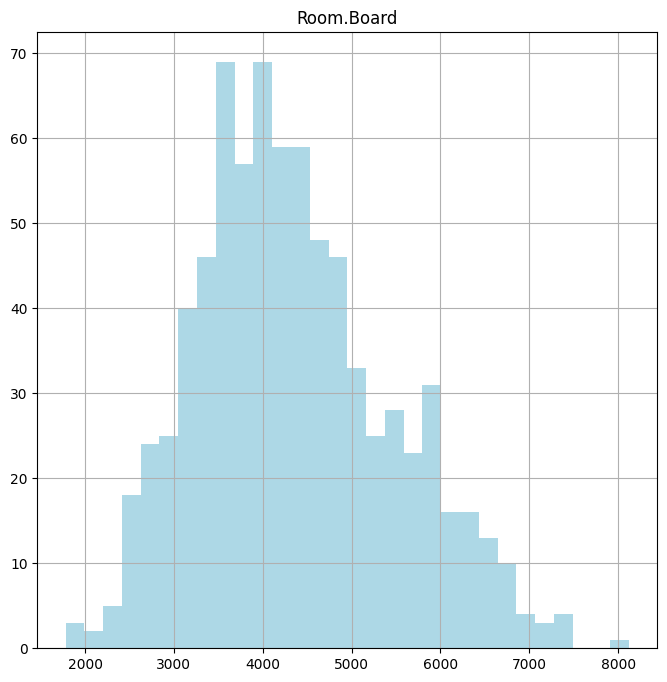

In [14]:
ig, ax = subplots(figsize = (8,8))
college.hist('Room.Board', color = 'lightblue', bins = 30, ax = ax);

There is a wide range for room and board costs, but the majority of the data is clustered in the $3,500 to 4,500 range.

**Summary of Findings**
 - Most colleges in this dataset have about 0-500 new students enrolled.
 - For most colleges, a large percentage of the staff (over 60%) have PhDs.
  - There is a wide range for room and board costs, but the majority of the data is clustered in the $3,500 to 4,500 range.

# Question #9

In [15]:
# Loading the Auto dataset and removing missing values.
Auto = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/Auto.csv")
Auto["horsepower"] = Auto["horsepower"].replace("?", pd.NA)

#### a) which of the predictors are quantitative and which are qualitative?

In [16]:
print(Auto.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


So, technically mpg, cylinders, displacement, weight, acceleration, year, and orgin are all numeric/quantitative. However, cylinders is actually a categorical/qualitative variable, and so is the orgin, because there are a finite amount of options (cylinders can only be 2, 4, 6 or 8 I think).

#### b) What is the range of each quantitative predictor? You can answer this using the min() and max() methods in numpy.

In [17]:
# List of the quantitative variables
variables = ['mpg', 'weight','displacement', 'acceleration', 'year']

# Calculate the range (Max - Min) for all of them at once
ranges = Auto[variables].max() - Auto[variables].min()

print(ranges)


mpg               37.6
weight          3527.0
displacement     387.0
acceleration      16.8
year              12.0
dtype: float64


#### c) What is the mean and standard deviation of each quantitative predictor?

In [18]:
# Coercing the qualitative variables to be considered qualitative, not quantitative
Auto['cylinders'] = Auto['cylinders'].astype('category')
Auto['origin'] = Auto['origin'].astype('category')


Auto.describe()

,mpg,displacement,weight,acceleration,year
count,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,193.532746,2970.261965,15.555668,75.994962
std,7.825804,104.379583,847.904119,2.749995,3.690005
min,9.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,104.000000,2223.000000,13.800000,73.000000
50%,23.000000,146.000000,2800.000000,15.500000,76.000000
75%,29.000000,262.000000,3609.000000,17.100000,79.000000
max,46.600000,455.000000,5140.000000,24.800000,82.000000


#### d) Now remove the 10th through 85th observations. What is the range, mean, and standard deviation of each predictor in the subset of the data that remains?

In [19]:
# Generate a list of index numbers from 9 to 84
rows_to_drop = list(range(9, 85))

# Drop the rows and save it into a new DataFrame
Auto_small = Auto.drop(index=rows_to_drop)

Auto_small.describe()

,mpg,displacement,weight,acceleration,year
count,321.000000,321.000000,321.000000,321.000000,321.000000
mean,24.438629,187.049844,2933.962617,15.723053,77.152648
std,7.908184,99.635385,810.642938,2.680514,3.111230
min,11.000000,68.000000,1649.000000,8.500000,70.000000
25%,18.000000,100.000000,2215.000000,14.000000,75.000000
50%,23.900000,145.000000,2795.000000,15.500000,77.000000
75%,30.700000,250.000000,3504.000000,17.300000,80.000000
max,46.600000,455.000000,4997.000000,24.800000,82.000000


#### e) Using the full dataset, investigate the predictors graphically, using scatterplots or other tools of your choice. Create some plots highlighting the relationships among the predictors. Comment on your findings.

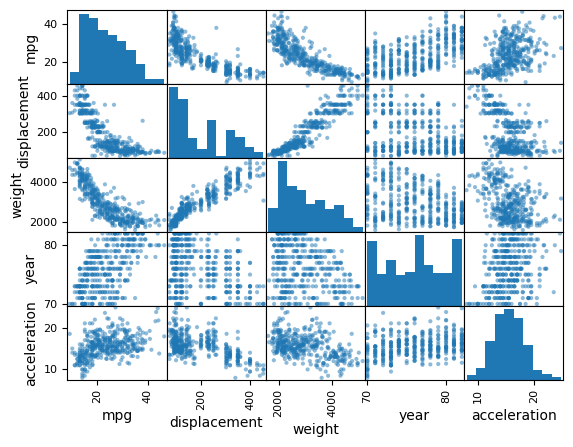

In [20]:
# Scatterplot matrix
pd.plotting.scatter_matrix(Auto[['mpg',
                                'displacement',
                                'weight',
                                 'year',
                                 'acceleration']]);

As displacement and weight decrease, mpg increases. So, lighter cars with a lower displacement have higher milage per gallon. Additionally, newer cars seem to have a better miles per gallon than older ones.

Cars weigh typically around 2000-3000 pounds, displacement is most common in the 0-100 range, and most cars are around 20-30  miles per gallon

#### f) Suppose that we wish to predict gas milage (mpg) on the basis of theother variables. Do your plots suggest any of the variables might be useful in predicting mpg?

Yes, my plots depict strong relationships with mpg for the weight and displacement. For both, they are inversely related. As weight and displacement decrease on the graph, mpg increases. There is a correlation, not exactly a causeation between the variables.

Newer cars (higher year) also seem to have slightly higher miles per gallon. As year increased so did mpg.

# Question #10

#### a) To begin, load in the Boston data set, which is part of the ISLP library.

In [21]:
boston = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/Boston.csv")
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


#### b) How many rows? How many columns? What do they represent?

In [22]:
boston.shape

(506, 14)

There are 506 rows, 14 variables (columns). Each row is a town. Variable descriptions:


    CRIM - per capita crime rate by town
    ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
    INDUS - proportion of non-retail business acres per town
    CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
    NOX - nitric oxides concentration (parts per 10 million)
    RM - average number of rooms per dwelling
    AGE - proportion of owner-occupied units built prior to 1940
    DIS - weighted distances to five Boston employment centres
    RAD - index of accessibility to radial highways
    TAX - full-value property-tax rate per $10,000
    PTRATIO - pupil-teacher ratio by town
    B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
    LSTAT - % lower status of the population
    MEDV - Median value of owner-occupied homes in $1000's

#### c) Make some pairwise scatterplots of the predictors (columns) in this dataset. Describe your findings

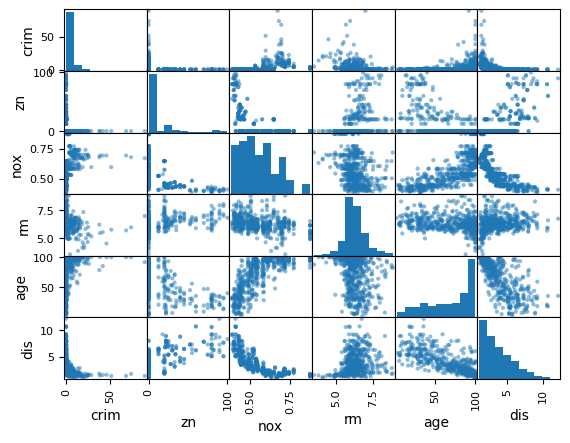

In [27]:
# Scatterplot matrix
pd.plotting.scatter_matrix(boston[['crim',
                                'zn',
                                 'nox',
                                 'rm',
                                   'age',
                                   'dis']]);

I don't see any strong correlations anywhere,there may be some relationship between the indus (proportion of non-retail buisness acres per town) and nox (nitric oxcides concentration) variables.

#### d) are any of the predictors associated with the per capita crime rate? If so, explain the relationship.

Assuming the per capita crime rate is stored in the variable crim, I don't see any clear correlations with other variables. Nox (nitrogen oxicide concentration) and age may have some positive correlation, and dis (weighted distances to 5 boston employment centers) may have some negative correlation with crim. However, I don't see how any of those variables could logically relate to crime rates.

e) Do any of the suburbs of Boston appear to have particularly high crime rates? Tax rates? Pupil-teacher ratios? Comment on the range of each predictor?

In [28]:
# Range of each predictor:
variables = ['crim',	'zn',	'indus',	'chas',	'nox',	'rm',	'age', 'dis',	'rad',	'tax',	'ptratio',	'lstat',	'medv']
ranges = boston[variables].max() - boston[variables].min()
print(ranges)

crim        88.96988
zn         100.00000
indus       27.28000
chas         1.00000
nox          0.48600
rm           5.21900
age         97.10000
dis         10.99690
rad         23.00000
tax        524.00000
ptratio      9.40000
lstat       36.24000
medv        45.00000
dtype: float64


Tax has the highest range, but zn and age also have large ranges

f) How many of the suberbs in this dataset bound the charles river?


In [29]:
boston['chas'].value_counts()


,count
chas,
0,471
1,35


35 suburbs bound the charles river.

g) What is the median pupil-teacher ratio among the towns in this dataset?

In [31]:
# Finding the median ptratio
median_val = np.mean(boston['ptratio'])
print(median_val)

18.455533596837945


Median pupil-teacher ratio is 18.46

#### h) Which suburb of Boston has lowest median value of owner-occupied homes? what are the values of the other predictors for that suburb, and how to those values compare to the overall ranges for those predictors? Comment on your findings.

In [42]:
lowest_median_index = boston['medv'].idxmin()
lowest_median_row = boston.loc[lowest_median_index]
print('The suburb/tract index with the lowest median house value is:', lowest_median_index)
print("\nFull Row Details:")
print(lowest_median_row)

The suburb/tract index with the lowest median house value is: 398

Full Row Details:
Unnamed: 0    399.0000
crim           38.3518
zn              0.0000
indus          18.1000
chas            0.0000
nox             0.6930
rm              5.4530
age           100.0000
dis             1.4896
rad            24.0000
tax           666.0000
ptratio        20.2000
lstat          30.5900
medv            5.0000
Name: 398, dtype: float64


In [44]:
# Row medians to compare to row 398
column_medians = boston.median()

print("Medians for all columns:")
print(column_medians)

Medians for all columns:
Unnamed: 0    253.50000
crim            0.25651
zn              0.00000
indus           9.69000
chas            0.00000
nox             0.53800
rm              6.20850
age            77.50000
dis             3.20745
rad             5.00000
tax           330.00000
ptratio        19.05000
lstat          11.36000
medv           21.20000
dtype: float64


Row 398 seems to be consistenly below the medians of other groups in most cases. Its crime rate is far below the median, it's tax is half of the datasets median, and the  proportion of non-retail business acres per town (indus) is half that of the average. In other variables however, it is  around the median.

In [ ]:
#### i) In this dataset, how many of the suburbs average more than seven rooms per dwelling? More than 8 rooms per dwelling? comment on the suburbs that average more than 8 rooms per dwelling.

In [50]:
# Suburbs with more than 7 rooms
rooms_over_7 = boston[boston['rm'] > 7]
print(f"Suburbs averaging > 7 rooms: {len(rooms_over_7)}")

# Suburbs with more than 8 rooms
rooms_over_8 = boston[boston['rm'] > 8]
print(f"Suburbs averaging > 8 rooms: {len(rooms_over_8)}")

# Filter for suburbs with > 8 rooms, then calculate the median for each column
medians_above_8 = boston[boston['rm'] > 8].median()

print("Medians for suburbs with > 8 rooms:")
print(medians_above_8)



Suburbs averaging > 7 rooms: 64
Suburbs averaging > 8 rooms: 13
Medians for suburbs with > 8 rooms:
Unnamed: 0    233.00000
crim            0.52014
zn              0.00000
indus           6.20000
chas            0.00000
nox             0.50700
rm              8.29700
age            78.30000
dis             2.89440
rad             7.00000
tax           307.00000
ptratio        17.40000
lstat           4.14000
medv           48.30000
dtype: float64


There are 64 towns with an average of over 7 rooms, 13 towns with an average of equal to or greater than 8. The towns with an average of over 8 seem to have lower lstat (% lower status of the population), and lower crime rates.